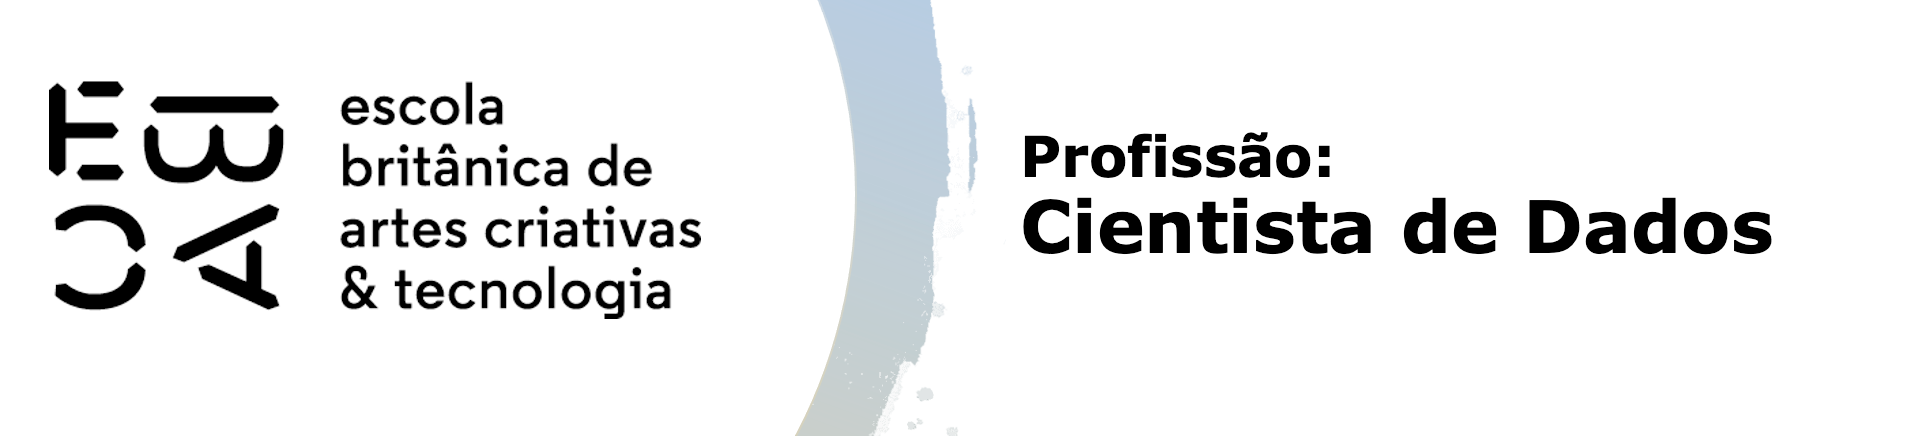

# Tarefa - Agrupamento hierárquico

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo agora é agrupar as sessões de acesso ao portal considerando o comportamento de acesso e informações da data, como a proximidade a uma data especial, fim de semana e o mês.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [5]:
# Verificando tamanho da base
print('Quantidade de linhas e colunas:', df.shape)

# Verificando tipos das variáveis
print('\nTipos das variáveis:')
print(df.dtypes)

# Verificando valores ausentes
print('\nValores ausentes por coluna:')
print(df.isna().sum())

# Estatísticas descritivas das variáveis numéricas
print('\nEstatísticas descritivas:')
df.describe()

Quantidade de linhas e colunas: (12330, 18)

Tipos das variáveis:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Valores ausentes por coluna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [6]:
print('Distribuição da variável Revenue:')
print(df['Revenue'].value_counts(dropna=False))
print('\nProporção:')
print(df['Revenue'].value_counts(normalize=True, dropna=False))

Distribuição da variável Revenue:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Proporção:
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


In [7]:
cols_cat = ['Month', 'VisitorType', 'Weekend']

for col in cols_cat:
    print(f'\nDistribuição de {col}:')
    print(df[col].value_counts(dropna=False))


Distribuição de Month:
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

Distribuição de VisitorType:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

Distribuição de Weekend:
Weekend
False    9462
True     2868
Name: count, dtype: int64


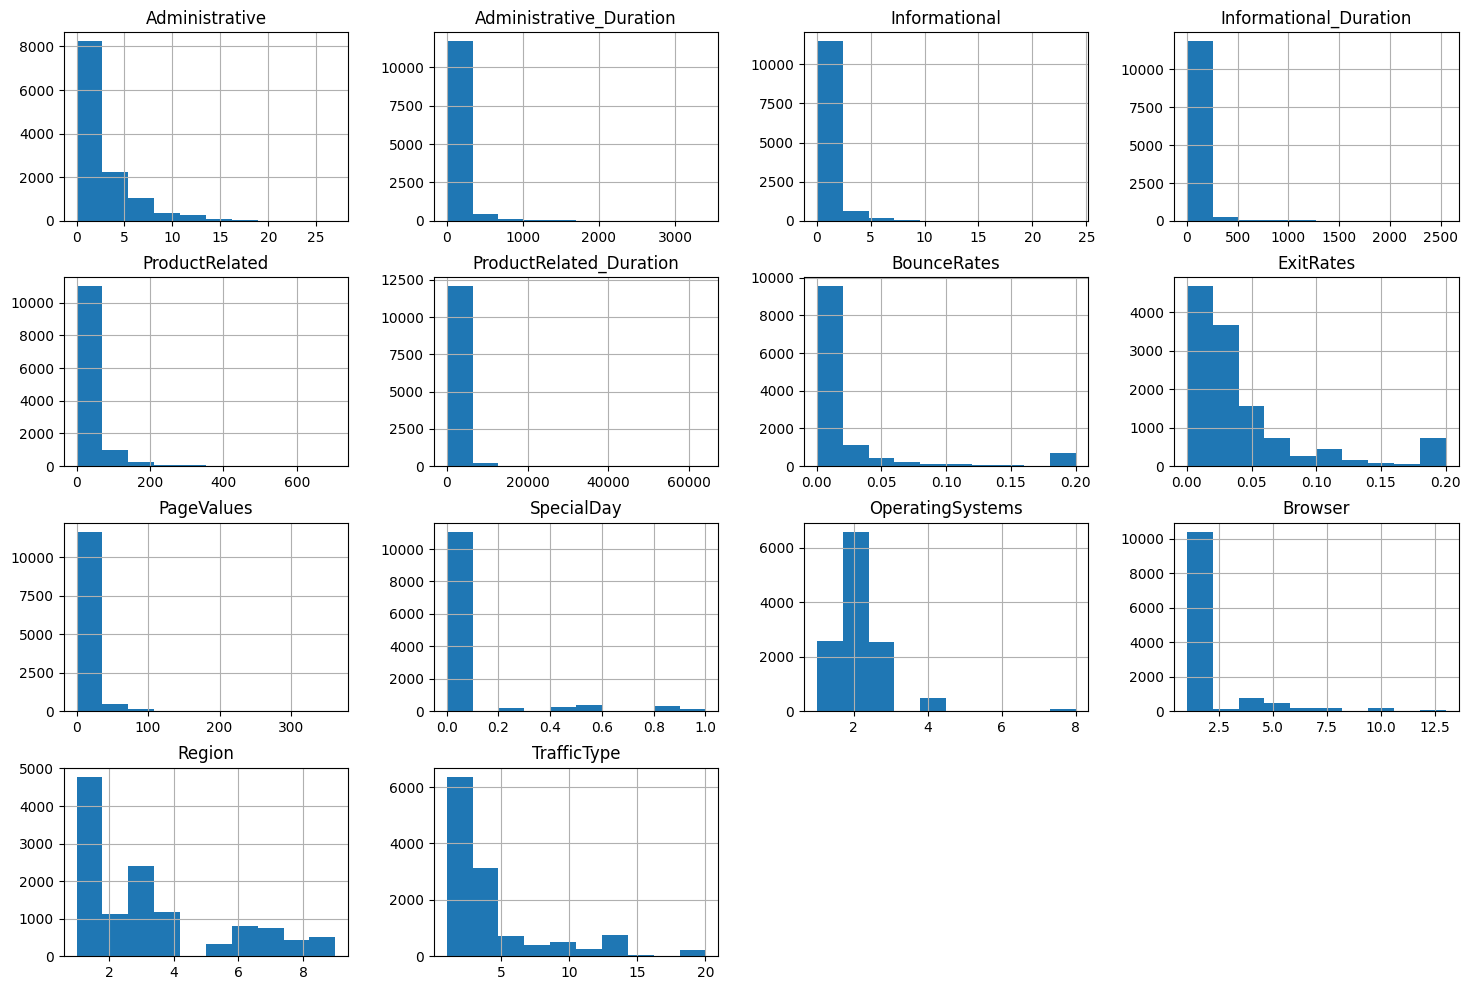

In [8]:
df.hist(figsize=(18, 12));

## Variáveis de agrupamento

Liste as variáveis que você vai querer utilizar. Essa é uma atividade importante do projeto, e tipicamente não a recebemos pronta. Não há resposta pronta ou correta, mas apenas critérios e a sua decisão. Os critérios são os seguintes:

- Selecione para o agrupamento variáveis que descrevam o padrão de navegação na sessão.
- Selecione variáveis que indiquem a característica da data.
- Não se esqueça de que você vai precisar realizar um tratamento especial para variáveis qualitativas.
- Trate adequadamente valores faltantes.

In [9]:
vars_agrupamento = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'SpecialDay',
    'Month',
    'VisitorType',
    'Weekend'
]

df_agrup = df[vars_agrupamento].copy()

print('Quantidade de linhas e colunas da base de agrupamento:', df_agrup.shape)
df_agrup.head()

Quantidade de linhas e colunas da base de agrupamento: (12330, 10)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,Month,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.0,Feb,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.0,Feb,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.0,Feb,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.0,Feb,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.0,Feb,Returning_Visitor,True


In [15]:
df_agrup_dummies = pd.get_dummies(
    df_agrup,
    columns=['Month', 'VisitorType', 'Weekend'],
    drop_first=True,
    dtype=int
)

print('Quantidade de linhas e colunas após criação das dummies:', df_agrup_dummies.shape)
df_agrup_dummies.head()

Quantidade de linhas e colunas após criação das dummies: (12330, 19)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,1,0
1,0,0.0,0,0.0,2,64.000000,0.0,0,1,0,0,0,0,0,0,0,0,1,0
2,0,0.0,0,0.0,1,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0.0,0,0.0,10,627.500000,0.0,0,1,0,0,0,0,0,0,0,0,1,1


In [14]:
scaler = StandardScaler()

df_agrup_padronizado = pd.DataFrame(
    scaler.fit_transform(df_agrup_dummies),
    columns=df_agrup_dummies.columns,
    index=df_agrup_dummies.index
)

print('Quantidade de linhas e colunas da base padronizada:', df_agrup_padronizado.shape)
df_agrup_padronizado.head()

Quantidade de linhas e colunas da base padronizada: (12330, 19)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,-0.308821,-0.403582,8.124707,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.550552
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.308821,-0.403582,8.124707,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.550552
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,-0.308821,-0.403582,8.124707,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.550552
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,-0.308821,-0.403582,8.124707,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.550552
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.308821,-0.403582,8.124707,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,1.816360


## Número de grupos

Nesta atividade vamos adotar uma abordagem bem pragmática e avaliar agrupamentos hierárquicos com 3 e 4 grupos, por estarem bem alinhados com uma expectativa e estratégia do diretor da empresa. 

*Atenção*: Cuidado se quiser fazer o dendrograma, pois com muitas observações ele pode ser mais complicado de fazer, e dependendo de como for o comando, ele pode travar o *kernell* do seu python.

In [17]:
Z = linkage(df_agrup_padronizado, method='ward')

print('Matriz de linkage criada com sucesso.')
print('Dimensão da matriz Z:', Z.shape)

Matriz de linkage criada com sucesso.
Dimensão da matriz Z: (12329, 4)


In [18]:
grupos_3 = fcluster(Z, t=3, criterion='maxclust')
grupos_4 = fcluster(Z, t=4, criterion='maxclust')

df['grupo_3'] = grupos_3
df['grupo_4'] = grupos_4

print('Distribuição dos grupos com 3 clusters:')
print(df['grupo_3'].value_counts().sort_index())

print('\nDistribuição dos grupos com 4 clusters:')
print(df['grupo_4'].value_counts().sort_index())

Distribuição dos grupos com 3 clusters:
grupo_3
1     910
2    3493
3    7927
Name: count, dtype: int64

Distribuição dos grupos com 4 clusters:
grupo_4
1     910
2    3493
3    1855
4    6072
Name: count, dtype: int64


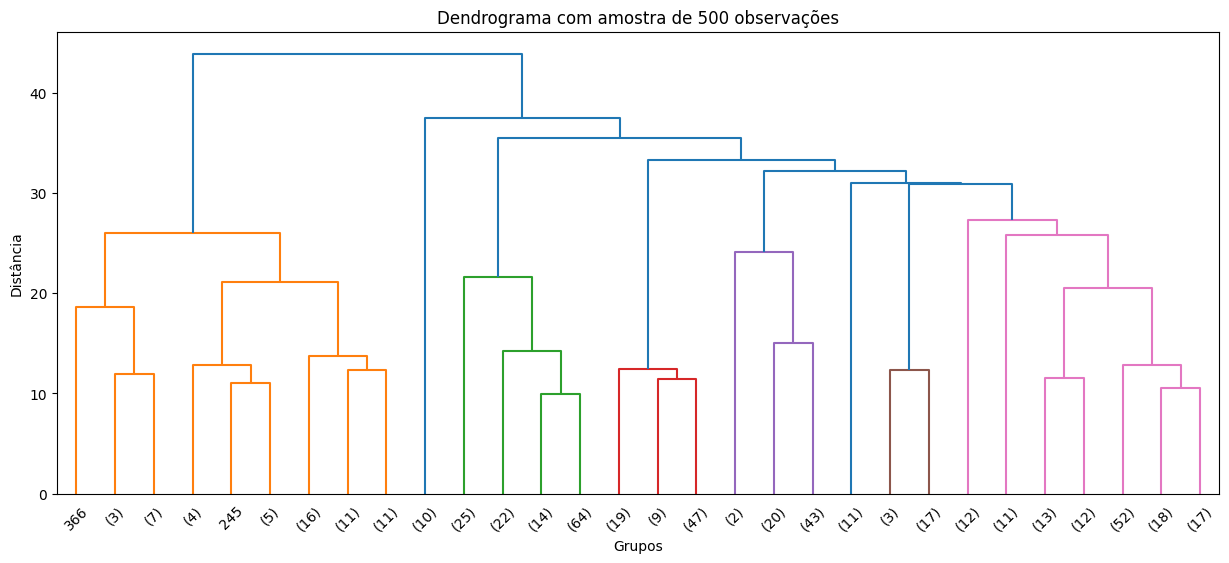

In [21]:
amostra = df_agrup_padronizado.sample(500, random_state=42)
Z_amostra = linkage(amostra, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(Z_amostra, truncate_mode='lastp', p=30)
plt.title('Dendrograma com amostra de 500 observações')
plt.xlabel('Grupos')
plt.ylabel('Distância')
plt.show()

## Avaliação dos grupos

Construa os agrupamentos com a técnica adequada que vimos em aula. Não se esqueça de tratar variáveis qualitativas, padronizar escalas das quantitativas, tratar valores faltantes e utilizar a distância correta.

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [22]:
vars_avaliacao = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'SpecialDay',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'Revenue'
]

avaliacao_3 = df.groupby('grupo_3')[vars_avaliacao].mean()
print('Médias das variáveis por grupo - solução com 3 grupos:')
avaliacao_3

Médias das variáveis por grupo - solução com 3 grupos:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,BounceRates,ExitRates,PageValues,Revenue
grupo_3,,,,,,,,,,,
1,6.949451,324.635490,2.663736,267.683440,113.738462,4575.865612,0.007473,0.006423,0.020175,8.559140,0.363736
2,1.745777,55.789378,0.326081,15.654343,25.421128,914.419906,0.207558,0.029766,0.052781,4.325374,0.092184
3,2.034061,63.858064,0.333796,15.992445,25.097893,930.126713,0.003229,0.020664,0.041423,6.271881,0.158320


In [23]:
avaliacao_4 = df.groupby('grupo_4')[vars_avaliacao].mean()
print('Médias das variáveis por grupo - solução com 4 grupos:')
avaliacao_4

Médias das variáveis por grupo - solução com 4 grupos:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,BounceRates,ExitRates,PageValues,Revenue
grupo_4,,,,,,,,,,,
1,6.949451,324.635490,2.663736,267.683440,113.738462,4575.865612,0.007473,0.006423,0.020175,8.559140,0.363736
2,1.745777,55.789378,0.326081,15.654343,25.421128,914.419906,0.207558,0.029766,0.052781,4.325374,0.092184
3,1.735310,56.185876,0.325067,16.908026,18.628571,753.016343,0.000000,0.022173,0.045254,3.891201,0.097035
4,2.125329,66.201922,0.336462,15.712735,27.074275,984.234047,0.004216,0.020203,0.040253,6.999180,0.177042


In [24]:
conv_3 = df.groupby('grupo_3')['Revenue'].mean().sort_values(ascending=False)
conv_4 = df.groupby('grupo_4')['Revenue'].mean().sort_values(ascending=False)

print('Taxa de conversão por grupo - 3 grupos:')
print(conv_3)

print('\nTaxa de conversão por grupo - 4 grupos:')
print(conv_4)

Taxa de conversão por grupo - 3 grupos:
grupo_3
1    0.363736
3    0.158320
2    0.092184
Name: Revenue, dtype: float64

Taxa de conversão por grupo - 4 grupos:
grupo_4
1    0.363736
4    0.177042
3    0.097035
2    0.092184
Name: Revenue, dtype: float64


In [25]:
bounce_3 = df.groupby('grupo_3')['BounceRates'].mean().sort_values()
bounce_4 = df.groupby('grupo_4')['BounceRates'].mean().sort_values()

print('Bounce rate médio por grupo - 3 grupos:')
print(bounce_3)

print('\nBounce rate médio por grupo - 4 grupos:')
print(bounce_4)

Bounce rate médio por grupo - 3 grupos:
grupo_3
1    0.006423
3    0.020664
2    0.029766
Name: BounceRates, dtype: float64

Bounce rate médio por grupo - 4 grupos:
grupo_4
1    0.006423
4    0.020203
3    0.022173
2    0.029766
Name: BounceRates, dtype: float64


In [26]:
resumo_3 = df.groupby('grupo_3').agg(
    qtd=('Revenue', 'size'),
    taxa_conversao=('Revenue', 'mean'),
    bounce_rate=('BounceRates', 'mean'),
    exit_rate=('ExitRates', 'mean'),
    page_values=('PageValues', 'mean')
).sort_values(by='taxa_conversao', ascending=False)

print('Resumo dos grupos - solução com 3 grupos:')
resumo_3

Resumo dos grupos - solução com 3 grupos:


,qtd,taxa_conversao,bounce_rate,exit_rate,page_values
grupo_3,,,,,
1,910,0.363736,0.006423,0.020175,8.559140
3,7927,0.158320,0.020664,0.041423,6.271881
2,3493,0.092184,0.029766,0.052781,4.325374


In [27]:
resumo_4 = df.groupby('grupo_4').agg(
    qtd=('Revenue', 'size'),
    taxa_conversao=('Revenue', 'mean'),
    bounce_rate=('BounceRates', 'mean'),
    exit_rate=('ExitRates', 'mean'),
    page_values=('PageValues', 'mean')
).sort_values(by='taxa_conversao', ascending=False)

print('Resumo dos grupos - solução com 4 grupos:')
resumo_4

Resumo dos grupos - solução com 4 grupos:


,qtd,taxa_conversao,bounce_rate,exit_rate,page_values
grupo_4,,,,,
1,910,0.363736,0.006423,0.020175,8.559140
4,6072,0.177042,0.020203,0.040253,6.999180
3,1855,0.097035,0.022173,0.045254,3.891201
2,3493,0.092184,0.029766,0.052781,4.325374


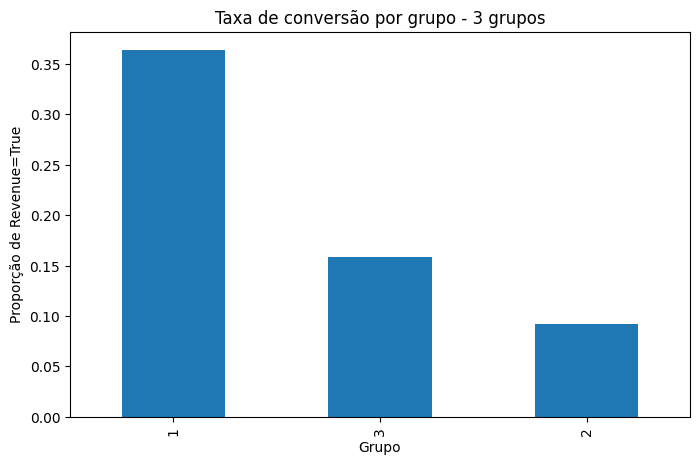

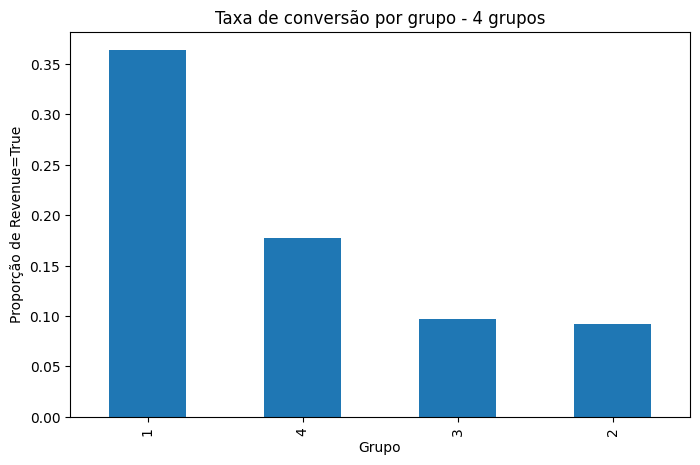

In [28]:
conv_3.plot(kind='bar', figsize=(8,5))
plt.title('Taxa de conversão por grupo - 3 grupos')
plt.ylabel('Proporção de Revenue=True')
plt.xlabel('Grupo')
plt.show()

conv_4.plot(kind='bar', figsize=(8,5))
plt.title('Taxa de conversão por grupo - 4 grupos')
plt.ylabel('Proporção de Revenue=True')
plt.xlabel('Grupo')
plt.show()

## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?

Comparando as soluções obtidas, a segmentação com **4 grupos** mostrou-se mais adequada, pois preserva o grupo com maior propensão à compra e permite diferenciar com mais clareza os perfis intermediários e os de menor desempenho.

O grupo com clientes mais propensos à compra é o **grupo 1**, tanto na solução com 3 grupos quanto na solução com 4 grupos. Esse grupo apresentou a **maior taxa de conversão**, além dos **menores valores médios de bounce rate e exit rate** e o **maior valor médio de PageValues**, indicando usuários mais qualificados e mais próximos da conversão.

Dessa forma, conclui-se que a solução com 4 grupos oferece uma segmentação mais informativa para análise do comportamento dos usuários e para apoio à tomada de decisão.